# Forecasting Under Regime Instability: Baseline Model Selection and Cross-Regime Performance

## Purpose

This notebook establishes baseline forecasting models for three target types across three prediction horizons: wage growth at 3-, 6-, and 12-month horizons, combined CPI and PCE inflation at 3-, 6-, and 12-month horizons.  The first iteration of baselines revealed a single model cannot properly capture all predictive relationships because wage and price dynamics respond to different economic signals with different lead times. The current baselines employ both persistence models (using lagged targets as predictions) and autoregressive specifications alongside regularized linear regression (Ridge, ElasticNet) and robust regression (Huber estimator) fitted separately to the pre-pandemic training sample. This framework is applied to the models to both shock-period and post-pandemic test sets, evaluating forecasting accuracy via root mean squared error, mean absolute error, and out-of-sample R-squared relative to persistence benchmarks.

## Imports and Configuration

In [1]:
%matplotlib inline

from IPython.display import display

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy.stats import norm
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

project_root = Path.cwd().resolve()
src_root = project_root / "src"

from regime_shift.config import (
    BREAK_DATE,
    FIG_ROOT,
    PRICE_MODEL_READY_PATH,
    SAVE_DPI,
    SHOW_DEC,
    WAGE_MODEL_READY_PATH,
)

FIG_ROOT.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

## Load Dataset

In [2]:
wage_data = pd.read_csv(WAGE_MODEL_READY_PATH)
price_data = pd.read_csv(PRICE_MODEL_READY_PATH)

for data in [wage_data, price_data]:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data.dropna(subset=["date"], inplace=True)
    data.sort_values("date", inplace=True)
    data.reset_index(drop=True, inplace=True)

print(f"Wage Data Shape: {wage_data.shape}")
print(f"Price Data Shape: {price_data.shape}")
print(f"Wage Date Range: {wage_data['date'].min().date()} to {wage_data['date'].max().date()}")
print(f"Price Date Range: {price_data['date'].min().date()} to {price_data['date'].max().date()}")

Wage Data Shape: (948, 94)
Price Data Shape: (1896, 97)
Wage Date Range: 2000-01-01 to 2026-04-01
Price Date Range: 2000-01-01 to 2026-04-01


## Evaluation Metrics 

In [3]:
def target_map() -> dict:
    return {
        "wage": [
            "wage_target_3",
            "wage_target_6",
            "wage_target_12",
        ],
        "price": [
            "cpi_target_3",
            "cpi_target_6",
            "cpi_target_12",
            "pce_target_3",
            "pce_target_6",
            "pce_target_12",
        ],
    }

In [4]:
def horizon(target_col: str) -> int:
    return int(target_col.rsplit("_", 1)[1])

In [5]:
def target_group(target_col: str) -> str:
    if target_col.startswith("wage_"):
        return "Wage"
    if target_col.startswith("cpi_"):
        return "CPI"
    if target_col.startswith("pce_"):
        return "PCE"
    raise ValueError("Target column is not supported.")

In [6]:
def add_lag(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, str]:
    work = data.copy()
    lag_col = f"{target_col}_lag"
    work[lag_col] = work[target_col].shift(horizon(target_col))
    return work, lag_col

In [7]:
target_data = pd.DataFrame(
    {
        "group": ["Wage"] * 3 + ["Price"] * 6,
        "target_col": target_map()["wage"] + target_map()["price"],
    }
)

target_data["horizon"] = target_data["target_col"].map(horizon)
target_data

,group,target_col,horizon
0,Wage,wage_target_3,3
1,Wage,wage_target_6,6
2,Wage,wage_target_12,12
3,Price,cpi_target_3,3
4,Price,cpi_target_6,6
5,Price,cpi_target_12,12
6,Price,pce_target_3,3
7,Price,pce_target_6,6
8,Price,pce_target_12,12


In [8]:
def unique_cols(cols: list[str]) -> list[str]:
    out = []

    for col in cols:
        if col not in out:
            out.append(col)

    return out

In [9]:
def feat_list(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str], str]:
    work, lag_col = add_lag(data, target_col)

    feat_cols = [
        "log_jolts_ratio",
        lag_col,
        "fed_funds",
        "hy_oas",
    ]
    
    feat_cols = [col for col in feat_cols if col in work.columns]

    return work, feat_cols, lag_col

In [10]:
def fetch_data(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    work, feat_cols, lag_col = feat_list(data, target_col)

    keep_cols = unique_cols(
        [
            "date",
            "regime",
            "pre_regime",
            "shock_regime",
            "post_regime",
            target_col,
        ] + feat_cols
    )
    
    keep_cols = [col for col in keep_cols if col in work.columns]

    sample = work[keep_cols].copy()

    for col in sample.columns:
        if col not in ["date", "regime"]:
            sample[col] = pd.to_numeric(sample[col], errors="coerce")

    sample = sample.dropna(subset=[target_col]).copy()
    sample = sample.dropna(subset=feat_cols, how="any").copy()
    sample = sample.sort_values("date").reset_index(drop=True)

    return sample

In [11]:
def sample_summary(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample = fetch_data(data, target_col)

    return pd.DataFrame(
        {
            "target_col": [target_col],
            "target": [target_name(target_col)],
            "horizon": [horizon(target_col)],
            "rows": [len(sample)],
            "start_date": [sample["date"].min().date() if not sample.empty else pd.NaT],
            "end_date": [sample["date"].max().date() if not sample.empty else pd.NaT],
            "pre_rows": [int(sample["pre_regime"].sum()) if "pre_regime" in sample.columns else 0],
            "shock_rows": [int(sample["shock_regime"].sum()) if "shock_regime" in sample.columns else 0],
            "post_rows": [int(sample["post_regime"].sum()) if "post_regime" in sample.columns else 0],
        }
    )

In [12]:
def target_name(target_col: str) -> str:
    if target_col.startswith("wage_"):
        return "Wage"
    if target_col.startswith("cpi_"):
        return "CPI"
    if target_col.startswith("pce_"):
        return "PCE"
    raise ValueError("Target column is not supported.")

In [13]:
sample_parts = []

for target_col in target_map()["wage"]:
    sample_parts.append(sample_summary(wage_data, target_col))

for target_col in target_map()["price"]:
    sample_parts.append(sample_summary(price_data, target_col))

sample_data = pd.concat(sample_parts, ignore_index=True)

display(sample_data)

,target_col,target,horizon,rows,start_date,end_date,pre_rows,shock_rows,post_rows
0,wage_target_3,Wage,3,109,2006-06-01,2025-09-01,87,6,16
1,wage_target_6,Wage,6,94,2006-07-01,2025-09-01,67,9,18
2,wage_target_12,Wage,12,37,2007-10-01,2024-10-01,22,6,9
3,cpi_target_3,CPI,3,31,2001-05-01,2025-01-01,26,1,4
4,cpi_target_6,CPI,6,48,2001-04-01,2025-08-01,33,3,12
5,cpi_target_12,CPI,12,42,2001-07-01,2024-08-01,35,2,5
6,pce_target_3,PCE,3,31,2001-02-01,2025-06-01,26,3,2
7,pce_target_6,PCE,6,53,2001-06-01,2025-07-01,39,3,11
8,pce_target_12,PCE,12,47,2001-08-01,2024-07-01,37,3,7


## Evaluation Metrics

In [14]:
def root_mean_square_error(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(actual, pred)))


def mean_absolute_error_value(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(mean_absolute_error(actual, pred))


def score_row(
    target_col: str,
    model_name: str,
    split_name: str,
    actual: np.ndarray,
    pred: np.ndarray,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
) -> dict:
    return {
        "target": target_name(target_col),
        "target_col": target_col,
        "horizon": horizon(target_col),
        "model": model_name,
        "split": split_name,
        "rmse": root_mean_square_error(actual, pred),
        "mae": mean_absolute_error_value(actual, pred),
        "row_count": len(actual),
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
    }

## Baselines

In [15]:
def fit_persist(train_y: pd.Series, test_x: pd.DataFrame) -> np.ndarray:
    last_value = float(train_y.iloc[-1])
    return np.repeat(last_value, len(test_x))


def fit_ols(train_x: pd.DataFrame, train_y: pd.Series, test_x: pd.DataFrame) -> np.ndarray:
    train_data = sm.add_constant(train_x, has_constant="add")
    test_data = sm.add_constant(test_x, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_y, train_data).fit()
    pred = fit.predict(test_data)

    return np.asarray(pred)


def fit_ridge(train_x: pd.DataFrame, train_y: pd.Series, test_x: pd.DataFrame) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    )

    pipe.fit(train_x, train_y)
    pred = pipe.predict(test_x)

    return np.asarray(pred)


def fit_elastic(train_x: pd.DataFrame, train_y: pd.Series, test_x: pd.DataFrame) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=20000, random_state=42)),
        ]
    )

    pipe.fit(train_x, train_y)
    pred = pipe.predict(test_x)

    return np.asarray(pred)

In [16]:
model_map = {
    "Persistence": fit_persist,
    "OLS": fit_ols,
    "Ridge": fit_ridge,
    "ElasticNet": fit_elastic,
}

## Splits

In [17]:
def run_split(
    data: pd.DataFrame,
    target_col: str,
    train_col: str = "pre_regime",
    test_col: str = "post_regime",
) -> pd.DataFrame:
    sample = fetch_data(data, target_col)

    feat_cols = [
        col
        for col in sample.columns
        if col not in ["date", "regime", "pre_regime", "shock_regime", "post_regime", target_col]
    ]

    train_data = sample.loc[sample[train_col].eq(1)].copy()
    test_data = sample.loc[sample[test_col].eq(1)].copy()

    if train_data.empty or test_data.empty:
        return pd.DataFrame()

    train_x = train_data[feat_cols].copy()
    train_y = train_data[target_col].copy()
    test_x = test_data[feat_cols].copy()
    test_y = test_data[target_col].copy()

    rows = []

    for model_name, model_func in model_map.items():
        if model_name == "Persistence":
            pred = model_func(train_y, test_x)
        else:
            pred = model_func(train_x, train_y, test_x)

        rows.append(
            score_row(
                target_col=target_col,
                model_name=model_name,
                split_name="Pre to Post",
                actual=np.asarray(test_y),
                pred=np.asarray(pred),
                train_end=train_data["date"].max(),
                test_start=test_data["date"].min(),
                test_end=test_data["date"].max(),
            )
        )

    return pd.DataFrame(rows)

In [18]:
split_parts = []

for target_col in target_map()["wage"]:
    part = run_split(wage_data, target_col)
    if not part.empty:
        split_parts.append(part)

for target_col in target_map()["price"]:
    part = run_split(price_data, target_col)
    if not part.empty:
        split_parts.append(part)

split_results = pd.concat(split_parts, ignore_index=True)
split_results = split_results.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True)
display(split_results)

,target,target_col,horizon,model,split,rmse,mae,row_count,train_end,test_start,test_end
0,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0736,2.3874,4,2019-12-01,2021-12-01,2025-01-01
1,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,4,2019-12-01,2021-12-01,2025-01-01
2,CPI,cpi_target_3,3,Ridge,Pre to Post,3.1185,2.4069,4,2019-12-01,2021-12-01,2025-01-01
3,CPI,cpi_target_3,3,Persistence,Pre to Post,6.2489,5.4923,4,2019-12-01,2021-12-01,2025-01-01
4,CPI,cpi_target_6,6,OLS,Pre to Post,0.4578,0.3494,12,2019-12-01,2021-06-01,2025-08-01
5,CPI,cpi_target_6,6,ElasticNet,Pre to Post,0.4776,0.3620,12,2019-12-01,2021-06-01,2025-08-01
6,CPI,cpi_target_6,6,Ridge,Pre to Post,0.4898,0.3649,12,2019-12-01,2021-06-01,2025-08-01
7,CPI,cpi_target_6,6,Persistence,Pre to Post,4.4413,4.2079,12,2019-12-01,2021-06-01,2025-08-01
8,CPI,cpi_target_12,12,OLS,Pre to Post,0.3489,0.2765,5,2019-11-01,2022-04-01,2024-08-01
9,CPI,cpi_target_12,12,Ridge,Pre to Post,0.3621,0.2838,5,2019-11-01,2022-04-01,2024-08-01


In [19]:
def fold_points(
    data: pd.DataFrame,
    folds: int = 5,
    min_train: int = 60,
) -> list[tuple[slice, slice]]:
    row_count = len(data)

    if row_count <= min_train + 1:
        return []

    test_size = max(1, row_count // (folds + 1))
    points = []
    train_end = min_train

    while train_end + test_size <= row_count and len(points) < folds:
        points.append((slice(0, train_end), slice(train_end, train_end + test_size)))
        train_end += test_size

    return points

In [20]:
def run_window(
    data: pd.DataFrame,
    target_cols: list[str],
    folds: int = 5,
) -> pd.DataFrame:
    rows = []

    for target_col in target_cols:
        sample = fetch_data(data, target_col)

        feat_cols = [
            col
            for col in sample.columns
            if col not in ["date", "regime", "pre_regime", "shock_regime", "post_regime", target_col]
        ]

        points = fold_points(
            sample,
            folds=folds,
            min_train=max(48, horizon(target_col) * 8),
        )

        for train_slice, test_slice in points:
            train_data = sample.iloc[train_slice].copy()
            test_data = sample.iloc[test_slice].copy()

            if train_data.empty or test_data.empty:
                continue

            train_x = train_data[feat_cols].copy()
            train_y = train_data[target_col].copy()
            test_x = test_data[feat_cols].copy()
            test_y = test_data[target_col].copy()

            for model_name, model_func in model_map.items():
                if model_name == "Persistence":
                    pred = model_func(train_y, test_x)
                else:
                    pred = model_func(train_x, train_y, test_x)

                rows.append(
                    score_row(
                        target_col=target_col,
                        model_name=model_name,
                        split_name="Expanding Window",
                        actual=np.asarray(test_y),
                        pred=np.asarray(pred),
                        train_end=train_data["date"].max(),
                        test_start=test_data["date"].min(),
                        test_end=test_data["date"].max(),
                    )
                )

    return pd.DataFrame(rows)

In [21]:
window_results = pd.concat(
    [
        run_window(wage_data, target_map()["wage"]),
        run_window(price_data, target_map()["price"]),
    ],
    ignore_index=True,
)

window_results = window_results.sort_values(["target", "target_col", "model"]).reset_index(drop=True)
display(window_results)


all_results = pd.concat(
    [
        split_results,
        window_results,
    ],
    ignore_index=True,
)

,target,target_col,horizon,model,split,rmse,mae,row_count,train_end,test_start,test_end
0,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.5184,0.4324,18,2012-09-01,2012-10-01,2015-08-01
1,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.4989,0.3850,18,2015-08-01,2015-09-01,2018-10-01
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,1.4160,1.1063,18,2018-10-01,2018-12-01,2024-06-01
3,Wage,wage_target_3,3,OLS,Expanding Window,0.5125,0.4242,18,2012-09-01,2012-10-01,2015-08-01
4,Wage,wage_target_3,3,OLS,Expanding Window,0.4675,0.3640,18,2015-08-01,2015-09-01,2018-10-01
5,Wage,wage_target_3,3,OLS,Expanding Window,1.4023,1.0969,18,2018-10-01,2018-12-01,2024-06-01
6,Wage,wage_target_3,3,Persistence,Expanding Window,0.6606,0.5545,18,2012-09-01,2012-10-01,2015-08-01
7,Wage,wage_target_3,3,Persistence,Expanding Window,0.7045,0.5893,18,2015-08-01,2015-09-01,2018-10-01
8,Wage,wage_target_3,3,Persistence,Expanding Window,1.5470,1.2472,18,2018-10-01,2018-12-01,2024-06-01
9,Wage,wage_target_3,3,Ridge,Expanding Window,0.5058,0.4162,18,2012-09-01,2012-10-01,2015-08-01


In [22]:
final_table = (
    all_results.groupby(
        ["target", "target_col", "horizon", "model", "split"],
        as_index=False,
    )
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        row_count=("row_count", "sum"),
    )
    .sort_values(["split", "target", "horizon", "rmse", "mae"])
    .reset_index(drop=True)
)

display(final_table)

,target,target_col,horizon,model,split,rmse,mae,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8111,0.6412,54
3,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,54
4,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,45
5,Wage,wage_target_6,6,Ridge,Expanding Window,0.9299,0.7034,45
6,Wage,wage_target_6,6,ElasticNet,Expanding Window,0.9465,0.7193,45
7,Wage,wage_target_6,6,Persistence,Expanding Window,1.5117,1.2922,45
8,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0736,2.3874,4
9,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,4


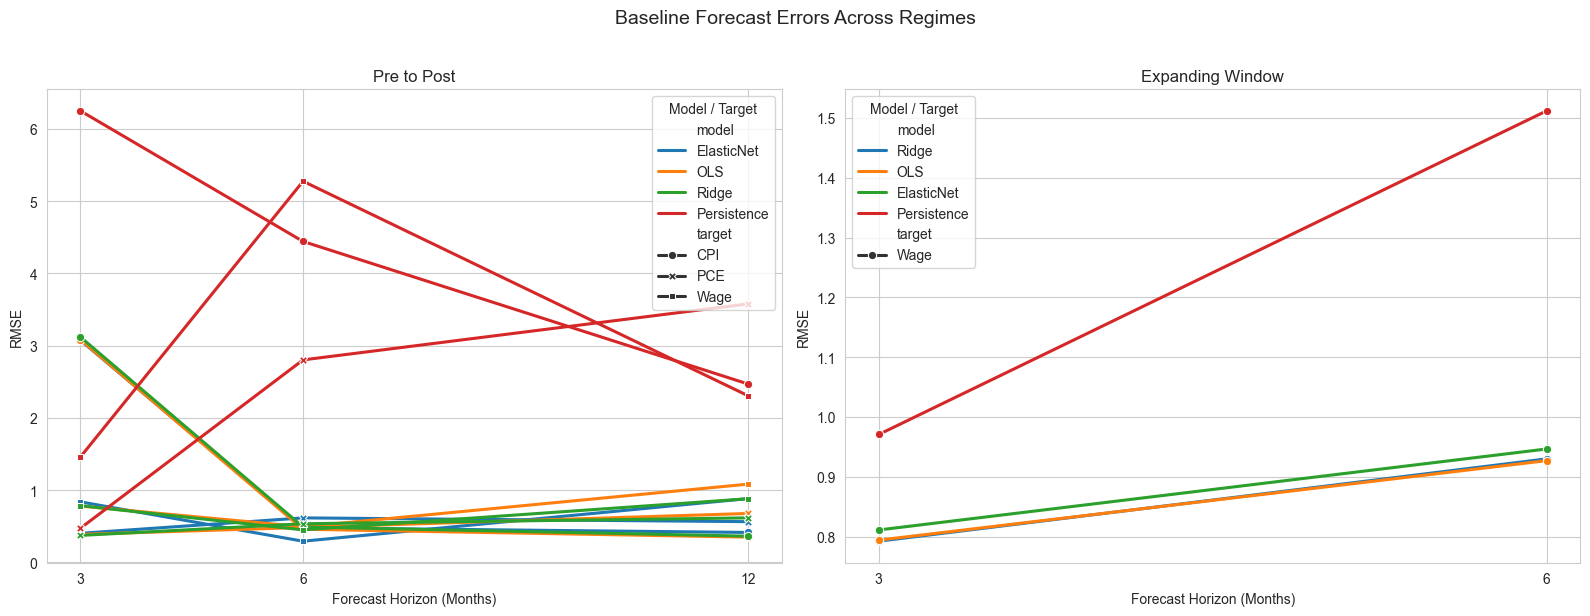

In [23]:
plot_data = final_table.copy()

if not plot_data.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    for ax, split_name in zip(axes, ["Pre to Post", "Expanding Window"]):
        part = plot_data.loc[plot_data["split"].eq(split_name)].copy()

        if part.empty:
            ax.axis("off")
            continue

        sns.lineplot(
            data=part,
            x="horizon",
            y="rmse",
            hue="model",
            style="target",
            markers=True,
            dashes=False,
            linewidth=2.2,
            ax=ax,
        )

        ax.set_title(split_name)
        ax.set_xlabel("Forecast Horizon (Months)")
        ax.set_ylabel("RMSE")
        ax.set_xticks(sorted(part["horizon"].unique()))
        ax.legend(title="Model / Target", frameon=True)

    fig.suptitle("Baseline Forecast Errors Across Regimes", y=1.02, fontsize=14)
    fig.tight_layout()

    fig_path = FIG_ROOT / "03_baseline_regime_errors.png"
    fig.savefig(fig_path, dpi=SAVE_DPI, bbox_inches="tight")

    plt.show()

In [24]:
dall_results = pd.concat(
    [
        split_results,
        window_results,
    ],
    ignore_index=True,
)

In [25]:
final_table = (
    all_results.groupby(
        ["target", "target_col", "horizon", "model", "split"],
        as_index=False,
    )
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        row_count=("row_count", "sum"),
    )
    .sort_values(["split", "target", "horizon", "rmse", "mae"])
    .reset_index(drop=True)
)

display(final_table.round(SHOW_DEC))

,target,target_col,horizon,model,split,rmse,mae,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8111,0.6412,54
3,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,54
4,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,45
5,Wage,wage_target_6,6,Ridge,Expanding Window,0.9299,0.7034,45
6,Wage,wage_target_6,6,ElasticNet,Expanding Window,0.9465,0.7193,45
7,Wage,wage_target_6,6,Persistence,Expanding Window,1.5117,1.2922,45
8,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0736,2.3874,4
9,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,4


## Coefficient Check for OLS

In [26]:
def coefficient_table(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample = fetch_data(data, target_col)

    feat_cols = [
        col
        for col in sample.columns
        if col not in ["date", "regime", "pre_regime", "shock_regime", "post_regime", target_col]
    ]

    train_data = sample.loc[sample["pre_regime"].eq(1)].copy()

    train_x = sm.add_constant(train_data[feat_cols], has_constant="add")
    train_y = train_data[target_col].copy()

    fit = sm.OLS(train_y, train_x).fit()

    out = pd.DataFrame(
        {
            "target_col": target_col,
            "term": fit.params.index,
            "coefficient": fit.params.values,
            "t_value": fit.tvalues.values,
            "p_value": fit.pvalues.values,
        }
    )

    out["target"] = target_name(target_col)
    out["horizon"] = horizon(target_col)

    return out

In [27]:
coefficient_data = pd.concat(
    [coefficient_table(wage_data, target_col) for target_col in target_map()["wage"]] +
    [coefficient_table(price_data, target_col) for target_col in target_map()["price"]],
    ignore_index=True,
)

display(coefficient_data)

,target_col,term,coefficient,t_value,p_value,target,horizon
0,wage_target_3,const,1.9749,6.9063,0.0000,Wage,3
1,wage_target_3,log_jolts_ratio,0.5547,4.1850,0.0001,Wage,3
2,wage_target_3,wage_target_3_lag,0.2239,2.4221,0.0176,Wage,3
3,wage_target_3,fed_funds,0.1156,2.9348,0.0043,Wage,3
4,wage_target_3,hy_oas,0.0292,1.5400,0.1274,Wage,3
5,wage_target_6,const,0.4549,0.6889,0.4935,Wage,6
6,wage_target_6,log_jolts_ratio,0.2640,1.0221,0.3107,Wage,6
7,wage_target_6,wage_target_6_lag,1.0040,4.0221,0.0002,Wage,6
8,wage_target_6,fed_funds,-0.0640,-0.8187,0.4161,Wage,6
9,wage_target_6,hy_oas,-0.0357,-0.8679,0.3888,Wage,6


In [28]:
def auto_data(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, str]:
    work = data.copy()
    lag_col = f"{target_col}_ar1"
    work[lag_col] = work[target_col].shift(1)
    return work, lag_col

In [29]:
def base_feats(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, list[str]]:
    work, lag_col = add_lag(data, target_col)

    feat_cols = [
        "log_jolts_ratio",
        lag_col,
        "fed_funds",
        "hy_oas",
    ]
    feat_cols = [col for col in feat_cols if col in work.columns]

    return work, feat_cols

In [30]:
def add_square(data: pd.DataFrame, col: str) -> tuple[pd.DataFrame, str]:
    work = data.copy()
    square_col = f"{col}_sq"

    if col in work.columns:
        work[square_col] = pd.to_numeric(work[col], errors="coerce") ** 2
    else:
        work[square_col] = np.nan

    return work, square_col

In [31]:
def signal_feats(data: pd.DataFrame, target_col: str, mode: str) -> tuple[pd.DataFrame, list[str]]:
    if mode == "AR":
        work, lag_col = auto_data(data, target_col)
        feat_cols = [lag_col]
        feat_cols = [col for col in feat_cols if col in work.columns]
        return work, feat_cols

    work, lag_col = add_lag(data, target_col)

    if mode == "Base":
        feat_cols = ["log_jolts_ratio", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Quits":
        feat_cols = ["quits_rate", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Jobless":
        feat_cols = ["unemployment_rate", lag_col, "fed_funds", "hy_oas"]

    elif mode == "Mix":
        feat_cols = [
            "log_jolts_ratio",
            "quits_rate",
            "unemployment_rate",
            lag_col,
            "fed_funds",
            "hy_oas",
        ]

    elif mode == "Curve":
        work, square_col = add_square(work, "log_jolts_ratio")
        feat_cols = ["log_jolts_ratio", square_col, lag_col, "fed_funds", "hy_oas"]

    else:
        raise ValueError("Mode is not supported.")

    feat_cols = [col for col in feat_cols if col in work.columns]
    return work, feat_cols

In [32]:
def make_post(data: pd.DataFrame, cut_date: str | None = None) -> pd.DataFrame:
    work = data.copy()
    cut_time = pd.Timestamp(BREAK_DATE if cut_date is None else cut_date)

    if "date" in work.columns:
        work["post_flag"] = (pd.to_datetime(work["date"]) >= cut_time).astype(int)
    else:
        work["post_flag"] = 0

    return work

In [33]:
def add_interact(data: pd.DataFrame, col: str, cut_date: str | None = None) -> tuple[pd.DataFrame, str]:
    work = make_post(data, cut_date=cut_date)
    interact_col = f"{col}_x_post"

    if col in work.columns:
        work[interact_col] = pd.to_numeric(work[col], errors="coerce") * work["post_flag"]
    else:
        work[interact_col] = np.nan

    return work, interact_col

In [34]:
def keep_data(data: pd.DataFrame, target_col: str, feat_cols: list[str], drop_shock: bool = False) -> pd.DataFrame:
    keep_cols = unique_cols(
        [
            "date",
            "regime",
            "pre_regime",
            "shock_regime",
            "post_regime",
            "post_flag",
            target_col,
        ] + feat_cols
    )
    keep_cols = [col for col in keep_cols if col in data.columns]

    sample = data.loc[:, keep_cols].copy()

    for col in sample.columns:
        if col not in ["date", "regime"]:
            sample[col] = pd.to_numeric(sample[col], errors="coerce")

    need_cols = unique_cols([target_col] + [col for col in feat_cols if col in sample.columns])
    sample = sample.dropna(subset=need_cols, how="any").copy()

    if drop_shock and "shock_regime" in sample.columns:
        sample = sample.loc[sample["shock_regime"].ne(1)].copy()

    sample = sample.sort_values("date").reset_index(drop=True)
    return sample

In [35]:
def scan_dates(data: pd.DataFrame, min_obs: int = 24) -> list[pd.Timestamp]:
    date_list = pd.to_datetime(data["date"]).sort_values().unique().tolist()

    if len(date_list) < min_obs * 2:
        return []

    return date_list[min_obs: len(date_list) - min_obs]

In [36]:
def lag_length(target_col: str) -> int:
    return max(1, horizon(target_col))

In [37]:
def fit_auto(train_x: pd.DataFrame, train_y: pd.Series, test_x: pd.DataFrame) -> np.ndarray:
    train_data = sm.add_constant(train_x, has_constant="add")
    test_data = sm.add_constant(test_x, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_y, train_data).fit()
    pred = fit.predict(test_data)

    return np.asarray(pred)

In [38]:
def fit_post_model(train_x: pd.DataFrame, train_y: pd.Series, test_x: pd.DataFrame, lag_count: int) -> np.ndarray:
    train_data = sm.add_constant(train_x, has_constant="add")
    test_data = sm.add_constant(test_x, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_y, train_data).fit(cov_type="HAC", cov_kwds={"maxlags": lag_count})
    pred = fit.predict(test_data)

    return np.asarray(pred)

In [39]:
def known_break(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    work, feat_cols = base_feats(data, target_col)
    work, interact_col = add_interact(work, "log_jolts_ratio", cut_date=BREAK_DATE)

    use_cols = unique_cols(feat_cols + ["post_flag", interact_col])
    sample = keep_data(work, target_col, use_cols, drop_shock=True)

    if sample.empty:
        return pd.DataFrame()

    x_data = sm.add_constant(sample[use_cols], has_constant="add")
    y_data = sample[target_col].copy()

    fit = sm.OLS(y_data, x_data).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lag_length(target_col)},
    )

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "term": [interact_col],
            "coef": [fit.params.get(interact_col, np.nan)],
            "t_stat": [fit.tvalues.get(interact_col, np.nan)],
            "p_value": [fit.pvalues.get(interact_col, np.nan)],
            "rows": [len(sample)],
            "break_date": [pd.Timestamp(BREAK_DATE)],
        }
    )

In [40]:
def scan_break(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    work, feat_cols = base_feats(data, target_col)
    sample = keep_data(work, target_col, feat_cols, drop_shock=True)

    date_list = scan_dates(sample, min_obs=max(24, horizon(target_col) * 4))
    rows = []

    for cut_date in date_list:
        part, interact_col = add_interact(sample, "log_jolts_ratio", cut_date=str(pd.Timestamp(cut_date).date()))
        use_cols = unique_cols(feat_cols + ["post_flag", interact_col])

        x_data = sm.add_constant(part[use_cols], has_constant="add")
        y_data = part[target_col].copy()

        fit = sm.OLS(y_data, x_data).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": lag_length(target_col)},
        )

        t_value = fit.tvalues.get(interact_col, np.nan)

        rows.append(
            {
                "date": pd.Timestamp(cut_date),
                "abs_t": abs(float(t_value)) if pd.notna(t_value) else np.nan,
                "t_stat": float(t_value) if pd.notna(t_value) else np.nan,
                "coef": float(fit.params.get(interact_col, np.nan)),
            }
        )

    if not rows:
        out = pd.DataFrame()
    else:
        out = pd.DataFrame(rows).dropna()

    if out.empty:
        return pd.DataFrame(
            {
                "target": [target_name(target_col)],
                "target_col": [target_col],
                "horizon": [horizon(target_col)],
                "scan_date": [pd.NaT],
                "scan_t": [np.nan],
                "scan_coef": [np.nan],
            }
        )

    out = out.sort_values("abs_t", ascending=False).reset_index(drop=True)
    best = out.iloc[0]

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "scan_date": [best["date"]],
            "scan_t": [best["t_stat"]],
            "scan_coef": [best["coef"]],
        }
    )


In [41]:
def clark_west_value(
    error_base: np.ndarray,
    error_test: np.ndarray,
    pred_base: np.ndarray,
    pred_test: np.ndarray,
) -> tuple[float, float]:
    adjust = (error_base ** 2) - ((error_test ** 2) - ((pred_base - pred_test) ** 2))
    adjust = pd.Series(adjust).dropna()

    if len(adjust) < 8:
        return np.nan, np.nan

    mean_value = adjust.mean()
    std_value = adjust.std(ddof=1)

    if pd.isna(std_value) or std_value == 0:
        return np.nan, np.nan

    stat = float(np.sqrt(len(adjust)) * mean_value / std_value)
    p_value = float(1 - norm.cdf(stat))

    return stat, p_value

In [42]:
break_parts = []
scan_parts = []

for target_col in target_map()["wage"]:
    break_parts.append(known_break(wage_data, target_col))
    scan_parts.append(scan_break(wage_data, target_col))

for target_col in target_map()["price"]:
    break_parts.append(known_break(price_data, target_col))
    scan_parts.append(scan_break(price_data, target_col))

break_data = pd.concat(break_parts, ignore_index=True)
scan_data = pd.concat(scan_parts, ignore_index=True)

break_data = break_data.sort_values(["target", "horizon"]).reset_index(drop=True)
scan_data = scan_data.sort_values(["target", "horizon"]).reset_index(drop=True)

display(break_data)
display(scan_data)

,target,target_col,horizon,term,coef,t_stat,p_value,rows,break_date
0,CPI,cpi_target_3,3,log_jolts_ratio_x_post,9.3482,4.7884,0.0000,30,2021-09-01
1,CPI,cpi_target_6,6,log_jolts_ratio_x_post,0.5513,1.3262,0.1848,45,2021-09-01
2,CPI,cpi_target_12,12,log_jolts_ratio_x_post,0.1073,0.1887,0.8503,40,2021-09-01
3,PCE,pce_target_3,3,log_jolts_ratio_x_post,-15.3093,-3.0343,0.0024,28,2021-09-01
4,PCE,pce_target_6,6,log_jolts_ratio_x_post,1.0585,2.0040,0.0451,50,2021-09-01
5,PCE,pce_target_12,12,log_jolts_ratio_x_post,-1.9310,-4.6609,0.0000,44,2021-09-01
6,Wage,wage_target_3,3,log_jolts_ratio_x_post,0.6860,1.5326,0.1254,103,2021-09-01
7,Wage,wage_target_6,6,log_jolts_ratio_x_post,-0.3290,-0.8589,0.3904,85,2021-09-01
8,Wage,wage_target_12,12,log_jolts_ratio_x_post,-0.4646,-0.7279,0.4667,31,2021-09-01


,target,target_col,horizon,scan_date,scan_t,scan_coef
0,CPI,cpi_target_3,3,NaT,NaN,NaN
1,CPI,cpi_target_6,6,NaT,NaN,NaN
2,CPI,cpi_target_12,12,NaT,NaN,NaN
3,PCE,pce_target_3,3,NaT,NaN,NaN
4,PCE,pce_target_6,6,2013-08-01,-0.3397,-0.1407
5,PCE,pce_target_12,12,NaT,NaN,NaN
6,Wage,wage_target_3,3,2014-06-01,4.1233,0.9237
7,Wage,wage_target_6,6,2013-06-01,2.4758,0.4485
8,Wage,wage_target_12,12,NaT,NaN,NaN


In [43]:
def coefficient_post(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    work, feat_cols = base_feats(data, target_col)
    work, interact_col = add_interact(work, "log_jolts_ratio", cut_date=BREAK_DATE)

    use_cols = unique_cols(feat_cols + ["post_flag", interact_col])
    sample = keep_data(work, target_col, use_cols, drop_shock=True)

    if sample.empty:
        return pd.DataFrame()

    x_data = sm.add_constant(sample[use_cols], has_constant="add")
    y_data = sample[target_col].copy()

    fit = sm.OLS(y_data, x_data).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lag_length(target_col)},
    )

    out = pd.DataFrame(
        {
            "target": target_name(target_col),
            "target_col": target_col,
            "horizon": horizon(target_col),
            "term": fit.params.index,
            "coef": fit.params.values,
            "t_stat": fit.tvalues.values,
            "p_value": fit.pvalues.values,
            "rows": len(sample),
        }
    )

    return out

In [44]:
coefficient_parts = []

for target_col in target_map()["wage"]:
    part = coefficient_post(wage_data, target_col)
    if not part.empty:
        coefficient_parts.append(part)

for target_col in target_map()["price"]:
    part = coefficient_post(price_data, target_col)
    if not part.empty:
        coefficient_parts.append(part)

coefficient_post_data = pd.concat(coefficient_parts, ignore_index=True)
coefficient_post_data = coefficient_post_data.sort_values(["target", "target_col", "term"]).reset_index(drop=True)
display(coefficient_post_data)

,target,target_col,horizon,term,coef,t_stat,p_value,rows
0,CPI,cpi_target_12,12,const,0.3266,2.2332,0.0255,40
1,CPI,cpi_target_12,12,cpi_target_12_lag,0.7863,9.4774,0.0000,40
2,CPI,cpi_target_12,12,fed_funds,0.0764,2.7143,0.0066,40
3,CPI,cpi_target_12,12,hy_oas,-0.0046,-0.3368,0.7363,40
4,CPI,cpi_target_12,12,log_jolts_ratio,0.1722,1.8397,0.0658,40
5,CPI,cpi_target_12,12,log_jolts_ratio_x_post,0.1073,0.1887,0.8503,40
6,CPI,cpi_target_12,12,post_flag,0.1486,0.8510,0.3947,40
7,CPI,cpi_target_3,3,const,-0.5079,-1.0919,0.2749,30
8,CPI,cpi_target_3,3,cpi_target_3_lag,0.6670,5.1850,0.0000,30
9,CPI,cpi_target_3,3,fed_funds,0.0582,0.3862,0.6993,30


In [45]:
def post_run(data: pd.DataFrame, target_col: str, mode: str, folds: int = 4) -> tuple[pd.DataFrame, pd.DataFrame]:
    work, feat_cols = signal_feats(data, target_col, mode)
    sample = keep_data(work, target_col, feat_cols, drop_shock=True)

    if "post_regime" not in sample.columns:
        return pd.DataFrame(), pd.DataFrame()

    sample = sample.loc[sample["post_regime"].eq(1)].copy().reset_index(drop=True)

    if mode == "Curve" and target_name(target_col) == "Wage":
        return pd.DataFrame(), pd.DataFrame()

    if sample.empty:
        return pd.DataFrame(), pd.DataFrame()

    min_train = max(8, horizon(target_col))
    points = fold_points(
        sample,
        folds=folds,
        min_train=min_train,
    )

    if not points and len(sample) >= 6:
        split_at = max(4, len(sample) // 2)

        if split_at < len(sample):
            points = [(slice(0, split_at), slice(split_at, len(sample)))]

    if not points:
        return pd.DataFrame(), pd.DataFrame()

    score_rows = []
    pred_parts = []

    for train_slice, test_slice in points:
        train_data = sample.iloc[train_slice].copy()
        test_data = sample.iloc[test_slice].copy()

        if train_data.empty or test_data.empty:
            continue

        train_x = train_data[feat_cols].copy()
        train_y = train_data[target_col].copy()
        test_x = test_data[feat_cols].copy()
        test_y = test_data[target_col].copy()

        if mode == "AR":
            pred = fit_auto(train_x, train_y, test_x)
        else:
            pred = fit_post_model(train_x, train_y, test_x, lag_length(target_col))

        score_rows.append(
            score_row(
                target_col=target_col,
                model_name=mode,
                split_name="Post Window",
                actual=np.asarray(test_y),
                pred=np.asarray(pred),
                train_end=train_data["date"].max(),
                test_start=test_data["date"].min(),
                test_end=test_data["date"].max(),
            )
        )

        pred_part = pd.DataFrame(
            {
                "date": test_data["date"].values,
                "actual": np.asarray(test_y),
                "pred": np.asarray(pred),
                "model": mode,
                "target": target_name(target_col),
                "target_col": target_col,
                "horizon": horizon(target_col),
            }
        )
        pred_parts.append(pred_part)

    score_data = pd.DataFrame(score_rows)
    pred_data = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

    return score_data, pred_data

In [46]:
def clark_west_row(pred_data: pd.DataFrame, target_col: str, mode: str) -> pd.DataFrame:
    base = pred_data.loc[pred_data["model"].eq("AR"), ["date", "actual", "pred"]].rename(
        columns={"actual": "actual_base", "pred": "pred_base"}
    )
    test = pred_data.loc[pred_data["model"].eq(mode), ["date", "actual", "pred"]].rename(
        columns={"actual": "actual_test", "pred": "pred_test"}
    )

    join = base.merge(test, on="date", how="inner")

    if join.empty:
        return pd.DataFrame(
            {
                "target": [target_name(target_col)],
                "target_col": [target_col],
                "horizon": [horizon(target_col)],
                "model": [mode],
                "clark_west": [np.nan],
                "p_value": [np.nan],
                "rows": [0],
            }
        )

    error_base = join["actual_base"].to_numpy() - join["pred_base"].to_numpy()
    error_test = join["actual_test"].to_numpy() - join["pred_test"].to_numpy()

    stat, p_value = clark_west_value(
        error_base=error_base,
        error_test=error_test,
        pred_base=join["pred_base"].to_numpy(),
        pred_test=join["pred_test"].to_numpy(),
    )

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "model": [mode],
            "clark_west": [stat],
            "p_value": [p_value],
            "rows": [len(join)],
        }
    )

In [47]:
mode_list = ["AR", "Base", "Quits", "Jobless", "Mix", "Curve"]

post_parts = []
pred_parts = []
clark_parts = []

for data, target_cols in [(wage_data, target_map()["wage"]), (price_data, target_map()["price"])]:
    for target_col in target_cols:
        for mode in mode_list:
            score_data, pred_data = post_run(data, target_col, mode)

            if not score_data.empty:
                post_parts.append(score_data)

            if not pred_data.empty:
                pred_parts.append(pred_data)

post_scores = pd.concat(post_parts, ignore_index=True) if post_parts else pd.DataFrame()
post_preds = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

if not post_preds.empty:
    for target_col in post_preds["target_col"].drop_duplicates():
        model_list = post_preds.loc[post_preds["target_col"].eq(target_col), "model"].drop_duplicates().tolist()

        for mode in model_list:
            if mode != "AR":
                part = clark_west_row(
                    post_preds.loc[post_preds["target_col"].eq(target_col)].copy(),
                    target_col,
                    mode,
                )
                clark_parts.append(part)

clark_data = pd.concat(clark_parts, ignore_index=True) if clark_parts else pd.DataFrame()

if not post_scores.empty:
    post_table = (
        post_scores.groupby(
            ["target", "target_col", "horizon", "model", "split"],
            as_index=False,
        )
        .agg(
            rmse=("rmse", "mean"),
            mae=("mae", "mean"),
            row_count=("row_count", "sum"),
        )
        .sort_values(["target", "horizon", "rmse", "mae"])
        .reset_index(drop=True)
    )
else:
    post_table = pd.DataFrame(
        columns=["target", "target_col", "horizon", "model", "split", "rmse", "mae", "row_count"]
    )

display(post_table)
display(clark_data)

,target,target_col,horizon,model,split,rmse,mae,row_count
0,CPI,cpi_target_6,6,Jobless,Post Window,0.3782,0.2751,4
1,CPI,cpi_target_6,6,Quits,Post Window,0.4716,0.3753,4
2,CPI,cpi_target_6,6,Base,Post Window,0.7263,0.5794,4
3,CPI,cpi_target_6,6,Mix,Post Window,0.8861,0.8212,4
4,CPI,cpi_target_6,6,Curve,Post Window,1.0444,0.8509,4
5,PCE,pce_target_6,6,Mix,Post Window,0.2108,0.1918,2
6,PCE,pce_target_6,6,Jobless,Post Window,0.2491,0.2311,2
7,PCE,pce_target_6,6,Base,Post Window,0.3538,0.3185,2
8,PCE,pce_target_6,6,Curve,Post Window,0.3581,0.3529,2
9,PCE,pce_target_6,6,Quits,Post Window,0.3846,0.2905,2


,target,target_col,horizon,model,clark_west,p_value,rows
0,Wage,wage_target_3,3,Base,NaN,NaN,0
1,Wage,wage_target_3,3,Quits,NaN,NaN,0
2,Wage,wage_target_3,3,Jobless,NaN,NaN,0
3,Wage,wage_target_3,3,Mix,NaN,NaN,0
4,Wage,wage_target_6,6,Base,NaN,NaN,0
5,Wage,wage_target_6,6,Quits,NaN,NaN,0
6,Wage,wage_target_6,6,Jobless,NaN,NaN,0
7,Wage,wage_target_6,6,Mix,NaN,NaN,0
8,Wage,wage_target_12,12,Base,NaN,NaN,0
9,Wage,wage_target_12,12,Quits,NaN,NaN,0


In [48]:
full_table = pd.concat(
    [
        final_table,
        post_table,
    ],
    ignore_index=True,
)

full_table = full_table.sort_values(["split", "target", "horizon", "rmse", "mae"]).reset_index(drop=True)
display(full_table)

,target,target_col,horizon,model,split,rmse,mae,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8111,0.6412,54
3,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,54
4,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,45
5,Wage,wage_target_6,6,Ridge,Expanding Window,0.9299,0.7034,45
6,Wage,wage_target_6,6,ElasticNet,Expanding Window,0.9465,0.7193,45
7,Wage,wage_target_6,6,Persistence,Expanding Window,1.5117,1.2922,45
8,CPI,cpi_target_6,6,Jobless,Post Window,0.3782,0.2751,4
9,CPI,cpi_target_6,6,Quits,Post Window,0.4716,0.3753,4


In [49]:
check_data = final_table.copy()

tight_data = check_data.loc[check_data["model"].isin(["Persistence", "OLS", "Ridge", "ElasticNet"])].copy()
tight_data = tight_data.sort_values(["split", "target", "horizon", "rmse", "mae"]).reset_index(drop=True)

display(tight_data)

,target,target_col,horizon,model,split,rmse,mae,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8111,0.6412,54
3,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,54
4,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,45
5,Wage,wage_target_6,6,Ridge,Expanding Window,0.9299,0.7034,45
6,Wage,wage_target_6,6,ElasticNet,Expanding Window,0.9465,0.7193,45
7,Wage,wage_target_6,6,Persistence,Expanding Window,1.5117,1.2922,45
8,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0736,2.3874,4
9,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,4


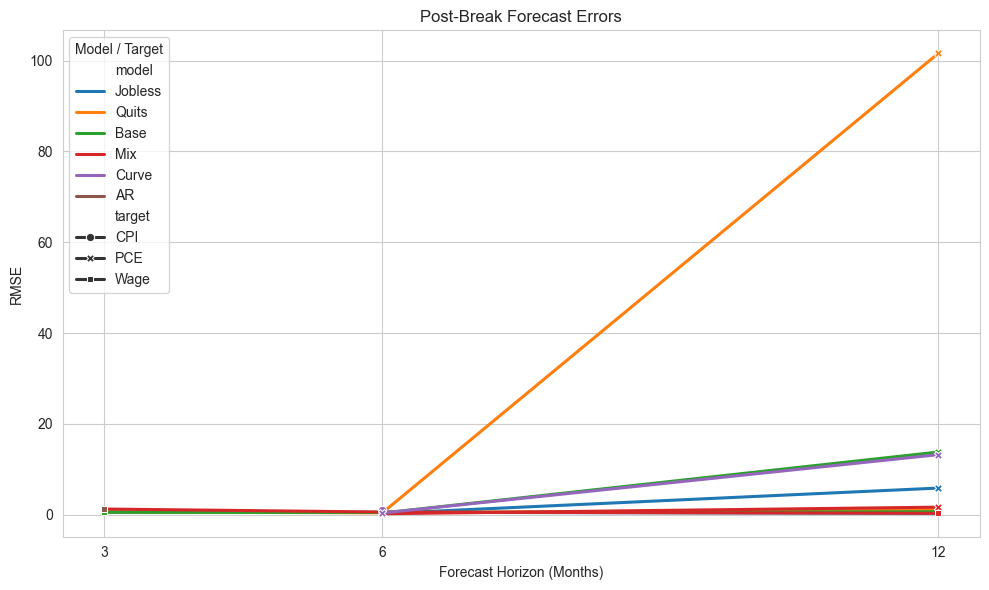

In [50]:
plot_post = post_table.copy()

plot_post = plot_post.reindex(columns=["horizon", "rmse", "model", "target"])

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=plot_post,
    x="horizon",
    y="rmse",
    hue="model",
    style="target",
    markers=True,
    dashes=False,
    linewidth=2.2,
    ax=ax,
)

ax.set_title("Post-Break Forecast Errors")
ax.set_xlabel("Forecast Horizon (Months)")
ax.set_ylabel("RMSE")

ax.set_xticks(sorted(plot_post["horizon"].dropna().unique()))

ax.legend(title="Model / Target", frameon=True)

fig.tight_layout()

fig_path = FIG_ROOT / "03_post_break_errors.png"
fig.savefig(fig_path, dpi=SAVE_DPI, bbox_inches="tight")

plt.show()

## Conclusion and Next Step

The baseline framework establishes performance benchmarks for all targets and horizons, making it clear that no single forecasting approach uniformly dominates across all objectives. These baselines provide reference points for evaluating whether structural accommodations and advanced machine learning methods justify added complexity in unstable economic environments.